# PROJECT PIPELINE: MACHINE LEARNING–BASED ANALYSIS OF SPECIFIC CAPACITANCE ACROSS VARYING PANI CONCENTRATION

## 1. ENVIRONMENT SETUP AND DEPENDENCIES

### 1.1 VIRTUAL ENVIRONMENT PACKAGES (REQUIREMENTS.TXT)

THE FOLLOWING PACKAGES MUST BE INSTALLED IN YOUR VENV TO RUN THIS PIPELINE:

- PANDAS>=1.5.0
- NUMPY>=1.23.0
- MATPLOTLIB>=3.6.0
- SEABORN>=0.12.0
- SCIKIT-LEARN>=1.2.0
- XGBOOST>=1.7.0
- LIGHTGBM>=3.3.0
- SHAP>=0.41.0
- SCIPY>=1.9.0

### 1.2 GLOBAL IMPORTS AND VISUALIZATION STANDARDS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import os
from IPython.display import display

warnings.filterwarnings('ignore')

In [2]:
# -----------------------------------------------------------------------------
# GLOBAL VISUALIZATION STANDARDS
# -----------------------------------------------------------------------------
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'figure.dpi': 500,
    'axes.grid': True,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.size': 12
})

## 2. DATA LOADING AND VALIDATION

### 2.1 LOAD DATASETS, CLEAN UNNAMED COLUMNS, AND DISPLAY SHAPE

In [3]:
import pandas as pd
import os

def load_and_interpret_pani_data(cv_dir: str, gcd_dir: str, concentrations: list) -> dict:
    """
    BATCH LOADS CV AND GCD DATASETS ACROSS VARIOUS PANI CONCENTRATIONS.
    CLEANS ARTIFACTS, INJECTS TARGET FEATURES, AND PERFORMS METADATA ANALYSIS.
    
    PARAMETERS:
    - cv_dir: STRING PATH TO CV DIRECTORY
    - gcd_dir: STRING PATH TO GCD DIRECTORY
    - concentrations: LIST OF INTEGERS REPRESENTING PANI %
    
    RETURNS:
    - DICTIONARY MAPPING CONCENTRATION -> {'CV': DataFrame, 'GCD': DataFrame}
    """
    data_vault = {}
    
    print("🔋 INITIATING ELECTROCHEMICAL DATA INGESTION...")
    
    for conc in concentrations:
        cv_path = os.path.join(cv_dir, f'AL203-PANI-{conc}.csv')
        gcd_path = os.path.join(gcd_dir, f'AL203-PANI-{conc}.csv')
        
        try:
            cv_df = pd.read_csv(cv_path)
            gcd_df = pd.read_csv(gcd_path)
            
            # DROP UNNAMED ARTIFACT COLUMNS
            cv_df = cv_df.loc[:, ~cv_df.columns.str.contains('^Unnamed')]
            gcd_df = gcd_df.loc[:, ~gcd_df.columns.str.contains('^Unnamed')]
            
            # INJECT CONCENTRATION AS A NUMERICAL FEATURE FOR PHASE 2 MERGE
            cv_df['PANI_Concentration'] = conc
            gcd_df['PANI_Concentration'] = conc
            
            # STORE IN VAULT
            data_vault[conc] = {'CV': cv_df, 'GCD': gcd_df}
            
            # --- DATA INTERPRETATION & EDA ---
            print(f"\n{'='*55}")
            print(f"🚀 CONCENTRATION LEVEL: {conc}% PANI")
            print(f"{'='*55}")
            
            print("\n[CV METADATA]")
            print(f"SHAPE: {cv_df.shape}")
            cv_df.info()
            
            print("\n[GCD METADATA]")
            print(f"SHAPE: {gcd_df.shape}")
            gcd_df.info()
            
        except FileNotFoundError as e:
            print(f"\n⚠️ FILE NOT FOUND EXPERIMENT ROUTE FAILED FOR {conc}%: {e}")
            
    return data_vault

# ==========================================
# EXECUTE DATA LOADING ARCHITECTURE
# ==========================================
# DEFINE THE CONCENTRATION ARRAY
pani_levels = [0, 5, 10, 15, 20]

# EXECUTE (ENSURE DIRECTORIES END WITHOUT A TRAILING SLASH FOR os.path.join)
data_vault = load_and_interpret_pani_data(
    cv_dir='../../DATASET/DATA/PANI/CV',
    gcd_dir='../../DATASET/DATA/PANI/GCD',
    concentrations=pani_levels
)

🔋 INITIATING ELECTROCHEMICAL DATA INGESTION...

🚀 CONCENTRATION LEVEL: 0% PANI

[CV METADATA]
SHAPE: (4780, 6)
<class 'pandas.DataFrame'>
RangeIndex: 4780 entries, 0 to 4779
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PANI                4780 non-null   int64  
 1   Scan_Rate           4780 non-null   int64  
 2   Potential           4780 non-null   float64
 3   Current             4780 non-null   float64
 4   CS                  4780 non-null   float64
 5   PANI_Concentration  4780 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 224.2 KB

[GCD METADATA]
SHAPE: (878, 6)
<class 'pandas.DataFrame'>
RangeIndex: 878 entries, 0 to 877
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PANI                878 non-null    int64  
 1   Current_Density     878 non-null    float64
 2   Time                878 

### 2.2 VALIDATE MISSING VALUES, DUPLICATES, AND CS RANGE

In [4]:
def validate_data(df: pd.DataFrame, dataset_name: str, target_col: str):
    """
    CHECKS FOR MISSING VALUES, DUPLICATES, OUTLIERS, 
    AND VALIDATES TARGET VARIABLE (Cs) RANGE.
    """
    print(f"\n{'='*40}")
    print(f"DATA VALIDATION: {dataset_name.upper()}")
    print(f"{'='*40}")
    
    # MISSING VALUES
    missing_count = df.isnull().sum().sum()
    print(f"TOTAL MISSING VALUES: {missing_count}")
    
    # DUPLICATES
    duplicate_count = df.duplicated().sum()
    print(f"TOTAL DUPLICATE ROWS: {duplicate_count}")
    
    # VALIDATE CS (SPECIFIC CAPACITANCE)
    if target_col in df.columns:
        print(f"\n{target_col.upper()} (TARGET) SUMMARY STATISTICS:")
        display(df[target_col].describe())
        
        # OUTLIER DETECTION VIA Z-SCORE
        z_scores = np.abs(stats.zscore(df[target_col].dropna()))
        outliers = np.where(z_scores > 3)[0]
        print(f"DETECTED OUTLIERS IN {target_col.upper()} (Z > 3): {len(outliers)}")
    else:
        print(f"TARGET COLUMN '{target_col}' NOT FOUND.")


# ==========================================
# EXECUTE BATCH DATA VALIDATION
# ==========================================
print("🧪 COMMENCING BATCH DATA VALIDATION ACROSS ALL CONCENTRATIONS...\n")

for conc in pani_levels:
    print(f"\n\n{'#'*60}")
    print(f"🔍 VALIDATING: AL2O3 DOPED WITH {conc}% PANI")
    print(f"{'#'*60}")
    
    # VALIDATE THE ISOLATED CV DataFrame
    validate_data(
        df=data_vault[conc]['CV'], 
        dataset_name=f"CV Dataset ({conc}%)", 
        target_col="CS"
    )
    
    # VALIDATE THE ISOLATED GCD DataFrame 
    validate_data(
        df=data_vault[conc]['GCD'], 
        dataset_name=f"GCD Dataset ({conc}%)", 
        target_col="GCD_CS"
    )

🧪 COMMENCING BATCH DATA VALIDATION ACROSS ALL CONCENTRATIONS...



############################################################
🔍 VALIDATING: AL2O3 DOPED WITH 0% PANI
############################################################

DATA VALIDATION: CV DATASET (0%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

CS (TARGET) SUMMARY STATISTICS:


count    4780.000000
mean       88.540023
std        11.077856
min        73.842330
25%        80.329420
50%        87.683990
75%        99.802440
max       111.191530
Name: CS, dtype: float64

DETECTED OUTLIERS IN CS (Z > 3): 0

DATA VALIDATION: GCD DATASET (0%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

GCD_CS (TARGET) SUMMARY STATISTICS:


count    878.000000
mean      48.077019
std        3.194727
min       39.912500
25%       45.294000
50%       48.649500
75%       50.441750
max       50.441750
Name: GCD_CS, dtype: float64

DETECTED OUTLIERS IN GCD_CS (Z > 3): 0


############################################################
🔍 VALIDATING: AL2O3 DOPED WITH 5% PANI
############################################################

DATA VALIDATION: CV DATASET (5%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

CS (TARGET) SUMMARY STATISTICS:


...

DETECTED OUTLIERS IN GCD_CS (Z > 3): 0


############################################################
🔍 VALIDATING: AL2O3 DOPED WITH 20% PANI
############################################################

DATA VALIDATION: CV DATASET (20%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

CS (TARGET) SUMMARY STATISTICS:


count    4772.000000
mean       40.867600
std        16.833375
min        23.211360
25%        28.260010
50%        36.172160
75%        56.001840
max        78.734470
Name: CS, dtype: float64

DETECTED OUTLIERS IN CS (Z > 3): 0

DATA VALIDATION: GCD DATASET (20%)
TOTAL MISSING VALUES: 0
TOTAL DUPLICATE ROWS: 0

GCD_CS (TARGET) SUMMARY STATISTICS:


count    415.000000
mean      24.729228
std        6.616303
min        6.610250
25%       22.932650
50%       29.266500
75%       29.266500
max       29.266500
Name: GCD_CS, dtype: float64

DETECTED OUTLIERS IN GCD_CS (Z > 3): 0


# 3. FEATURE ENGINEERING

In [26]:
def engineer_isolated_features(cv_df: pd.DataFrame, gcd_df: pd.DataFrame) -> tuple:
    """
    STANDARDIZES TARGET NAMES, DERIVES POTENTIAL WINDOWS, 
    EXTRACTS DISCHARGE_TIME (GCD) AND CV_AREA (CV) FROM RAW ARRAYS, 
    AND AGGREGATES BOTH DATASETS TO PREVENT TIME-SERIES LEAKAGE.
    """
    
    # ==========================================
    # 1. STANDARDIZE TARGET COLUMNS
    # ==========================================
    cv_clean = cv_df.rename(columns={'CS': 'Cs'})
    gcd_clean = gcd_df.rename(columns={'GCD_CS': 'Cs'})
    
    # ==========================================
    # 2. DERIVE POTENTIAL WINDOWS
    # ==========================================
    # CV: WINDOW IS CONSTANT ACROSS A SPECIFIC SCAN RATE
    cv_clean['Potential_Window'] = cv_clean.groupby('Scan_Rate')['Potential'].transform(lambda x: x.max() - x.min())
    
    # GCD: WINDOW IS CONSTANT ACROSS A SPECIFIC CURRENT DENSITY RUN
    gcd_clean['Potential_Window'] = gcd_clean.groupby('Current_Density')['Potential'].transform(lambda x: x.max() - x.min())
    
    # ==========================================
    # 3. EXTRACT KINETIC FEATURES (DISCHARGE TIME & CV AREA)
    # ==========================================
    
    # --- GCD: EXTRACT DISCHARGE TIME ---
    def calculate_dt(group):
        # FIND MAX POTENTIAL INDEX (START OF DISCHARGE)
        max_idx = group['Potential'].idxmax()
        discharge_curve = group.loc[max_idx:]
        
        # DT = FINAL TIME - TIME AT MAX POTENTIAL
        dt = discharge_curve['Time'].iloc[-1] - discharge_curve['Time'].iloc[0]
        return dt

    dt_mapping = gcd_clean.groupby('Current_Density').apply(calculate_dt, include_groups=False)
    gcd_clean['Discharge_Time'] = gcd_clean['Current_Density'].map(dt_mapping)

    # --- CV: EXTRACT INTEGRAL AREA ---
    def calculate_cv_area(group):
        # USE TRAPEZOIDAL NUMERICAL INTEGRATION TO FIND THE AREA UNDER THE CURVE
        # ABSOLUTE VALUE PREVENTS NEGATIVE AREAS BASED ON SCAN DIRECTION
        integral_area = np.abs(np.trapezoid(group['Current'], group['Potential']))
        return integral_area
        
    area_mapping = cv_clean.groupby('Scan_Rate').apply(calculate_cv_area, include_groups=False)
    cv_clean['CV_Area'] = cv_clean['Scan_Rate'].map(area_mapping)

    # ==========================================
    # 4. COLLAPSE CV AND GCD TO SCALAR FEATURES
    # ==========================================
    
    # AGGREGATE CV (NOW INCLUDING CV_AREA)
    cv_aggregated = cv_clean.groupby('Scan_Rate').agg({
        'Cs': 'first',
        'Potential_Window': 'first',
        'CV_Area': 'first',
        'PANI_Concentration': 'first'
    }).reset_index()

    # AGGREGATE GCD (INCLUDING DISCHARGE_TIME)
    gcd_aggregated = gcd_clean.groupby('Current_Density').agg({
        'Cs': 'first',
        'Potential_Window': 'first',
        'Discharge_Time': 'first',
        'PANI_Concentration': 'first'
    }).reset_index()

    return cv_aggregated, gcd_aggregated

# EXECUTE AS BEFORE
engineered_vault = {}
for conc in pani_levels:
    cv_raw = data_vault[conc]['CV']
    gcd_raw = data_vault[conc]['GCD']
    cv_processed, gcd_processed = engineer_isolated_features(cv_raw, gcd_raw)
    engineered_vault[conc] = {'CV': cv_processed, 'GCD': gcd_processed}

## CREATE PHASE 2 MASTER DATAFRAMES

In [27]:
# CONCATENATE ALL ISOLATED, AGGREGATED DATAFRAMES INTO MASTER TENSORS
master_cv_df = pd.concat([engineered_vault[c]['CV'] for c in pani_levels], ignore_index=True)
master_gcd_df = pd.concat([engineered_vault[c]['GCD'] for c in pani_levels], ignore_index=True)

# SETTING GLOBAL SEABORN STYLE FOR ACADEMIC VISUALS
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

## 4. EXPLORATORY DATA ANALYSIS AND VISUALIZATION 

### 4.1 DISTRIBUTION AND METHOD COMPARISON FOR Cs

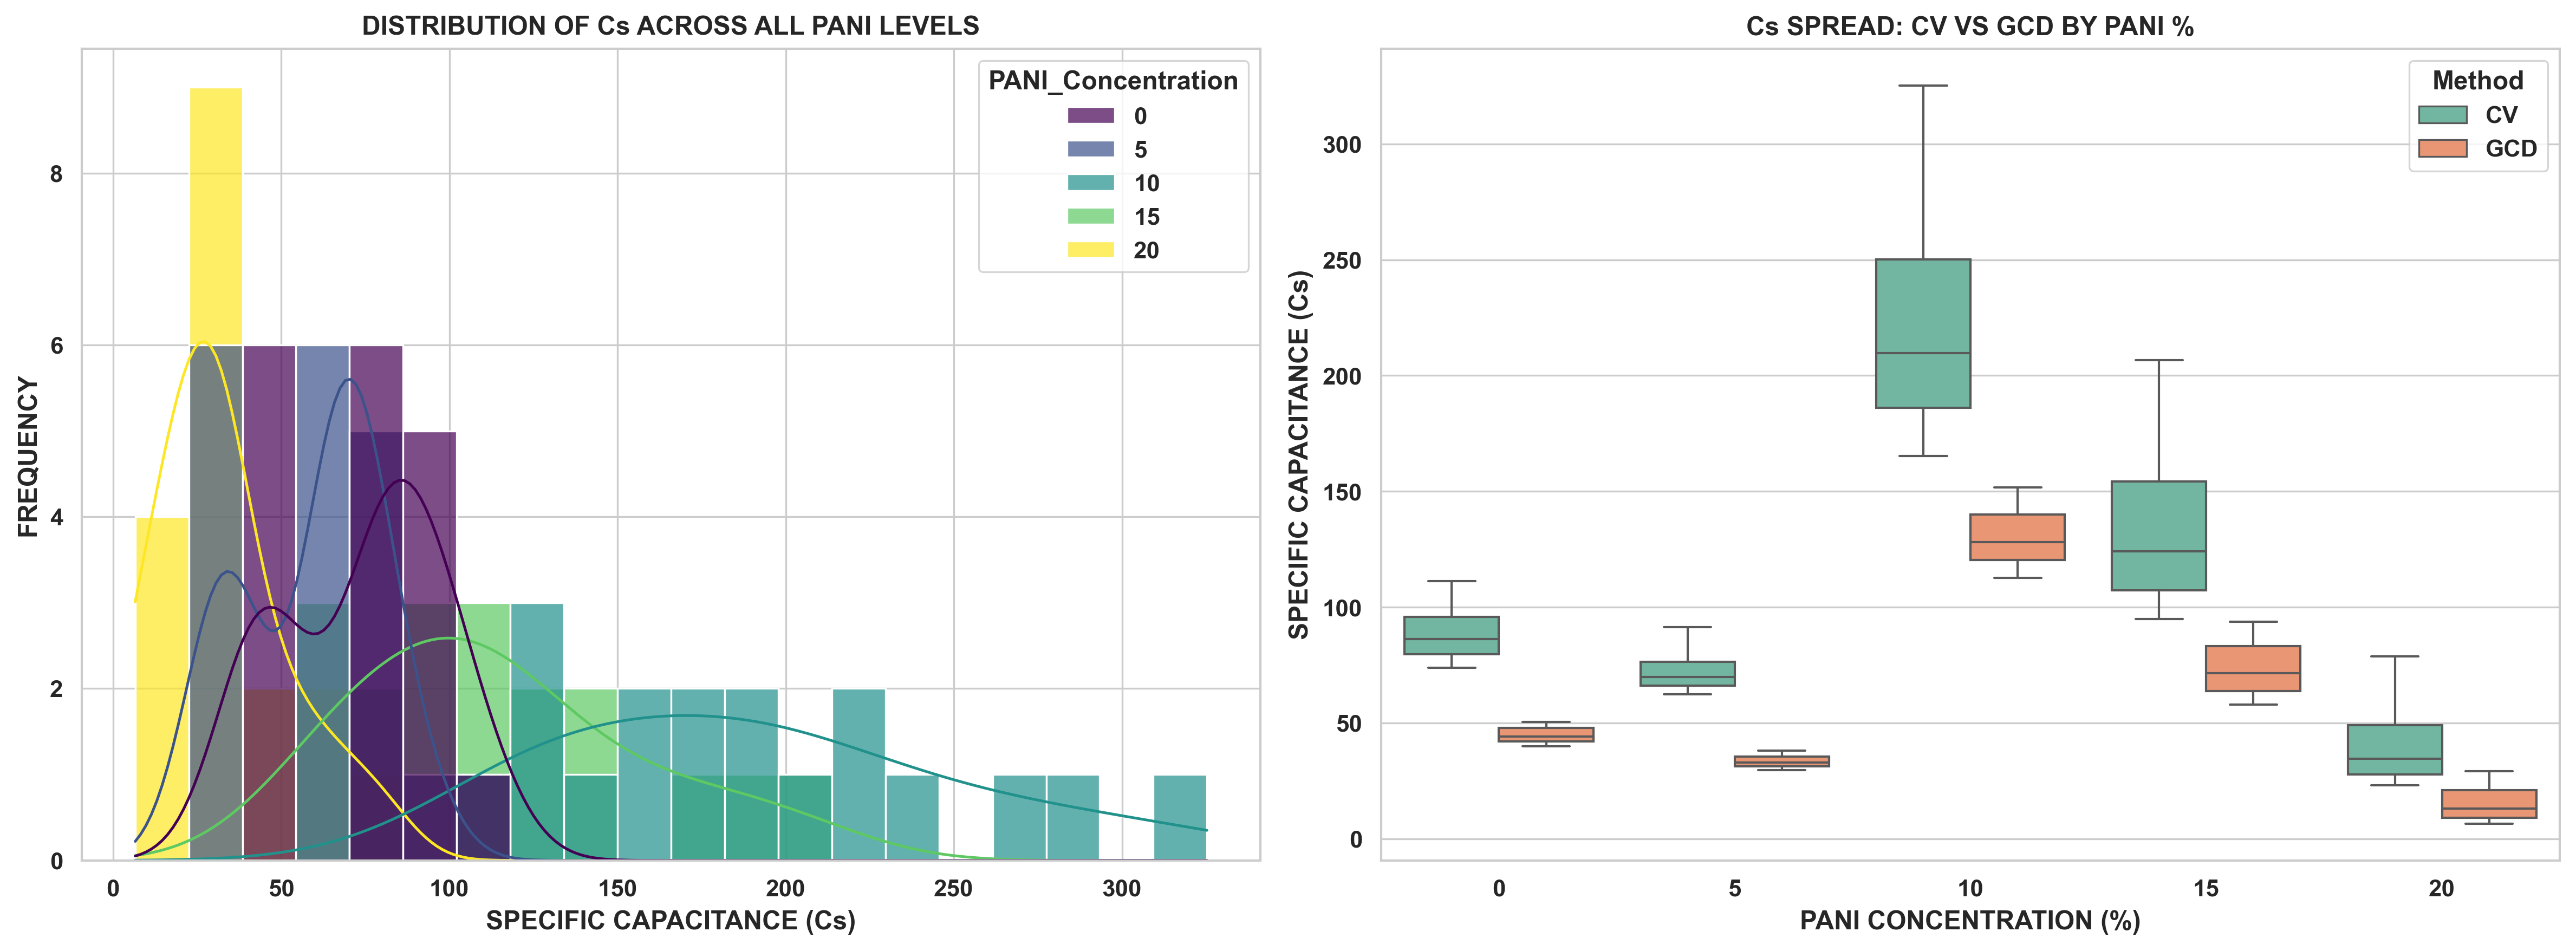

In [28]:
def plot_master_distributions(cv_df: pd.DataFrame, gcd_df: pd.DataFrame):
    """
    VISUALIZES THE DISTRIBUTION AND SPREAD OF Cs ACROSS CONCENTRATIONS.
    """
    # ADD METHOD FLAGS FOR EASY COMBINED PLOTTING
    cv_temp = cv_df.copy()
    cv_temp['Method'] = 'CV'
    gcd_temp = gcd_df.copy()
    gcd_temp['Method'] = 'GCD'
    
    combined_df = pd.concat([cv_temp, gcd_temp], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

    # HISTOGRAM: DISTRIBUTION BY PANI CONCENTRATION
    sns.histplot(data=combined_df, x='Cs', hue='PANI_Concentration', kde=True, 
                 palette='viridis', bins=20, alpha=0.7, ax=axes[0])
    axes[0].set_title('DISTRIBUTION OF Cs ACROSS ALL PANI LEVELS', fontweight='bold')
    axes[0].set_xlabel('SPECIFIC CAPACITANCE (Cs)')
    axes[0].set_ylabel('FREQUENCY')

    # BOXPLOT: SPREAD COMPARISON BY METHOD AND CONCENTRATION
    sns.boxplot(data=combined_df, x='PANI_Concentration', y='Cs', hue='Method', 
                palette='Set2', ax=axes[1])
    axes[1].set_title('Cs SPREAD: CV VS GCD BY PANI %', fontweight='bold')
    axes[1].set_xlabel('PANI CONCENTRATION (%)')
    axes[1].set_ylabel('SPECIFIC CAPACITANCE (Cs)')

    plt.tight_layout()
    plt.show()

plot_master_distributions(master_cv_df, master_gcd_df)

### 4.2 CV AND GCD ELECTROCHEMICAL VISUALIZATIONS

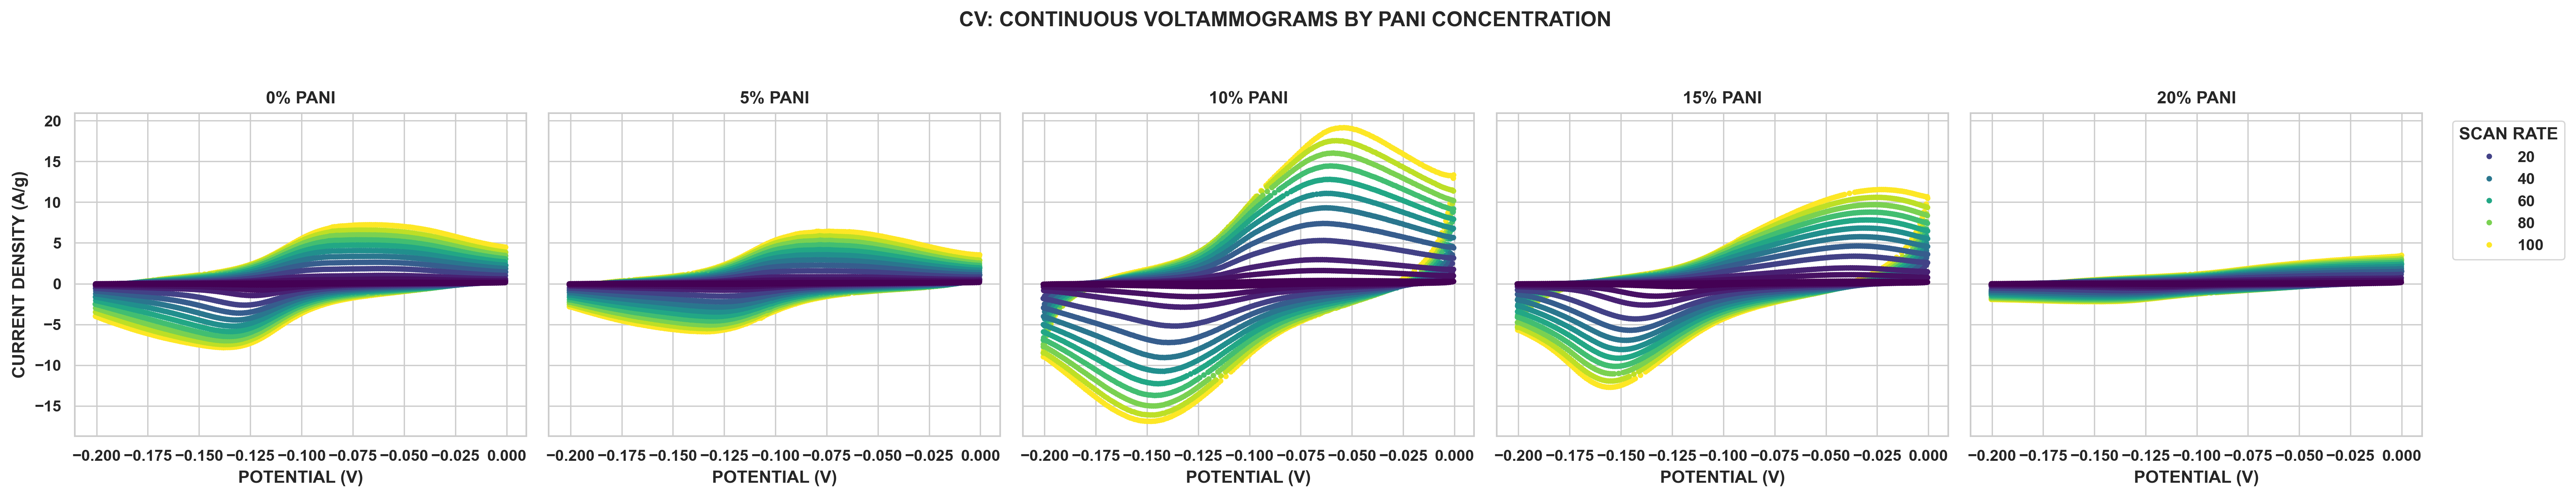

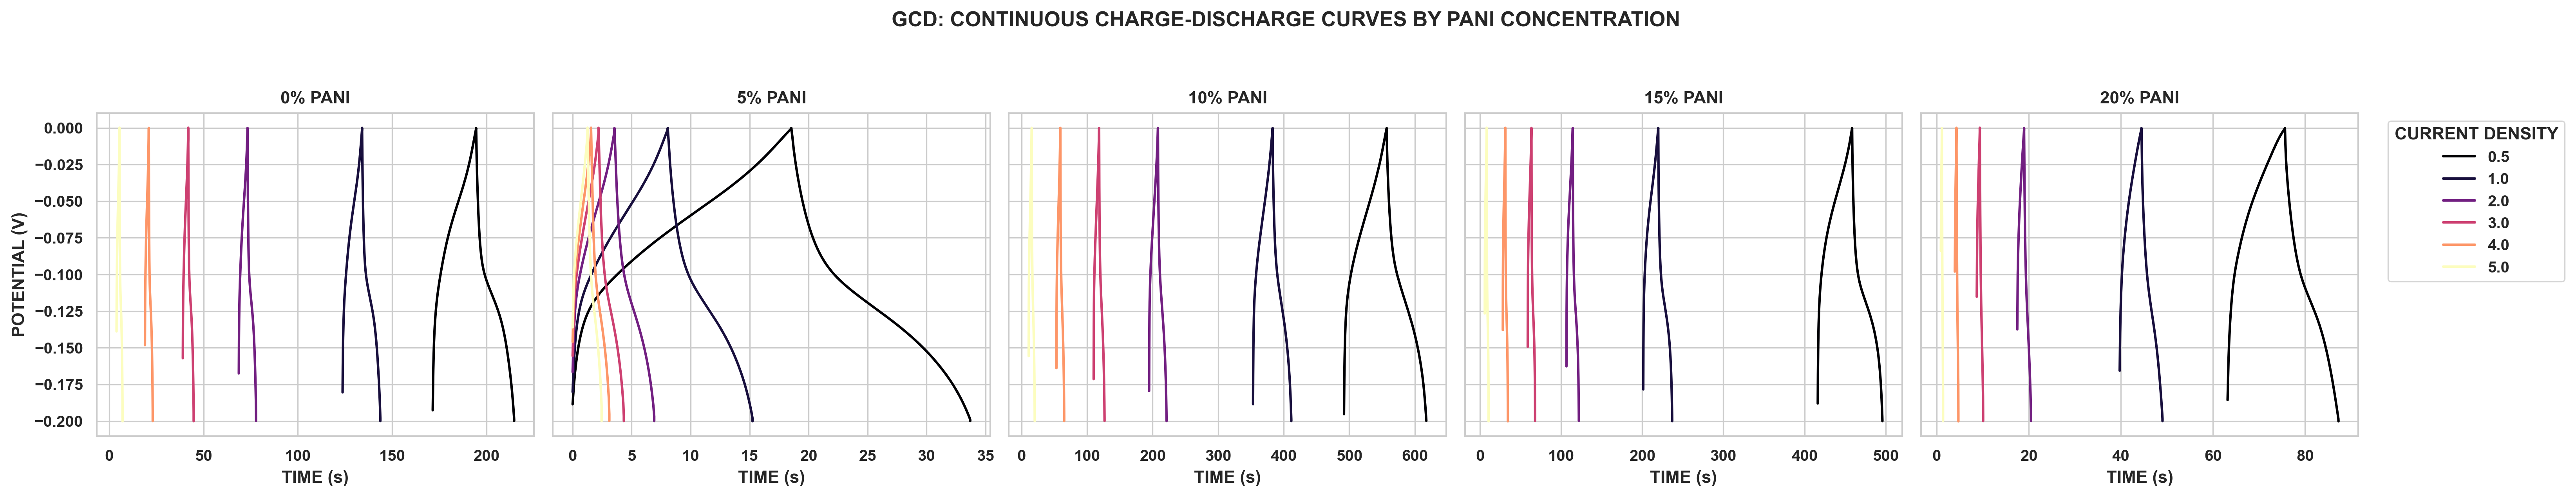

In [29]:
def plot_continuous_electrochemistry_grid(raw_vault: dict, levels: list):
    """
    PLOTS THE RAW, CONTINUOUS TIME-SERIES DATA FOR CV AND GCD 
    SUBPLOTTED ACROSS ALL PANI CONCENTRATIONS.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    # ==========================================
    # 1. CV: CURRENT DENSITY VS POTENTIAL (HYSTERESIS LOOPS)
    # ==========================================
    fig_cv, axes_cv = plt.subplots(1, 5, figsize=(22, 4), sharey=True, dpi=300)
    fig_cv.suptitle('CV: CONTINUOUS VOLTAMMOGRAMS BY PANI CONCENTRATION', fontweight='bold', y=1.05)
    
    for idx, conc in enumerate(levels):
        raw_cv = raw_vault[conc]['CV']
        
        # SCATTERPLOT RECREATES THE CONTINUOUS LOOP
        sns.scatterplot(data=raw_cv, x='Potential', y='Current', hue='Scan_Rate', 
                        palette='viridis', s=10, edgecolor=None, ax=axes_cv[idx], legend=(idx==4))
        
        axes_cv[idx].set_title(f'{conc}% PANI')
        axes_cv[idx].set_xlabel('POTENTIAL (V)')
        if idx == 0: axes_cv[idx].set_ylabel('CURRENT DENSITY (A/g)')
        
        # ONLY SHOW LEGEND ON THE LAST PLOT TO SAVE SPACE
        if idx == 4:
            axes_cv[idx].legend(title='SCAN RATE', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # ==========================================
    # 2. GCD: POTENTIAL VS TIME (CHARGE-DISCHARGE CURVES)
    # ==========================================
    fig_gcd, axes_gcd = plt.subplots(1, 5, figsize=(22, 4), sharey=True, dpi=300)
    fig_gcd.suptitle('GCD: CONTINUOUS CHARGE-DISCHARGE CURVES BY PANI CONCENTRATION', fontweight='bold', y=1.05)
    
    for idx, conc in enumerate(levels):
        raw_gcd = raw_vault[conc]['GCD']
        
        # LINEPLOT TRACKS POTENTIAL OVER TIME
        sns.lineplot(data=raw_gcd, x='Time', y='Potential', hue='Current_Density', 
                     palette='magma', linewidth=1.5, ax=axes_gcd[idx], legend=(idx==4))
        
        axes_gcd[idx].set_title(f'{conc}% PANI')
        axes_gcd[idx].set_xlabel('TIME (s)')
        if idx == 0: axes_gcd[idx].set_ylabel('POTENTIAL (V)')
        
        if idx == 4:
            axes_gcd[idx].legend(title='CURRENT DENSITY', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# EXECUTE THE PLOTTING USING THE RAW DATA VAULT
plot_continuous_electrochemistry_grid(data_vault, pani_levels)

### RATE CAPABILITY

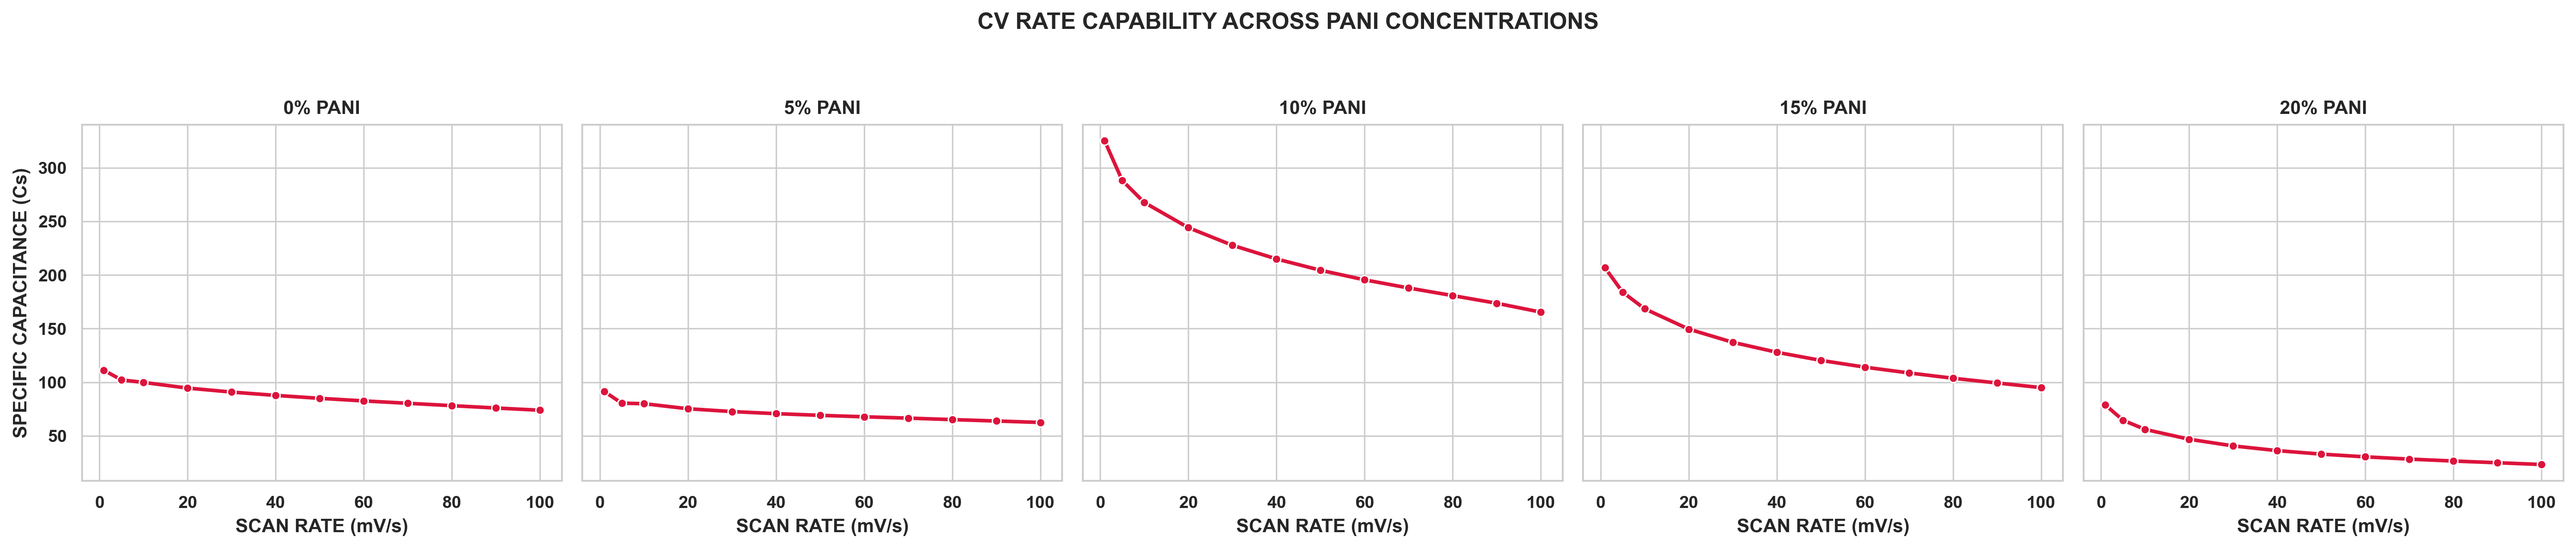

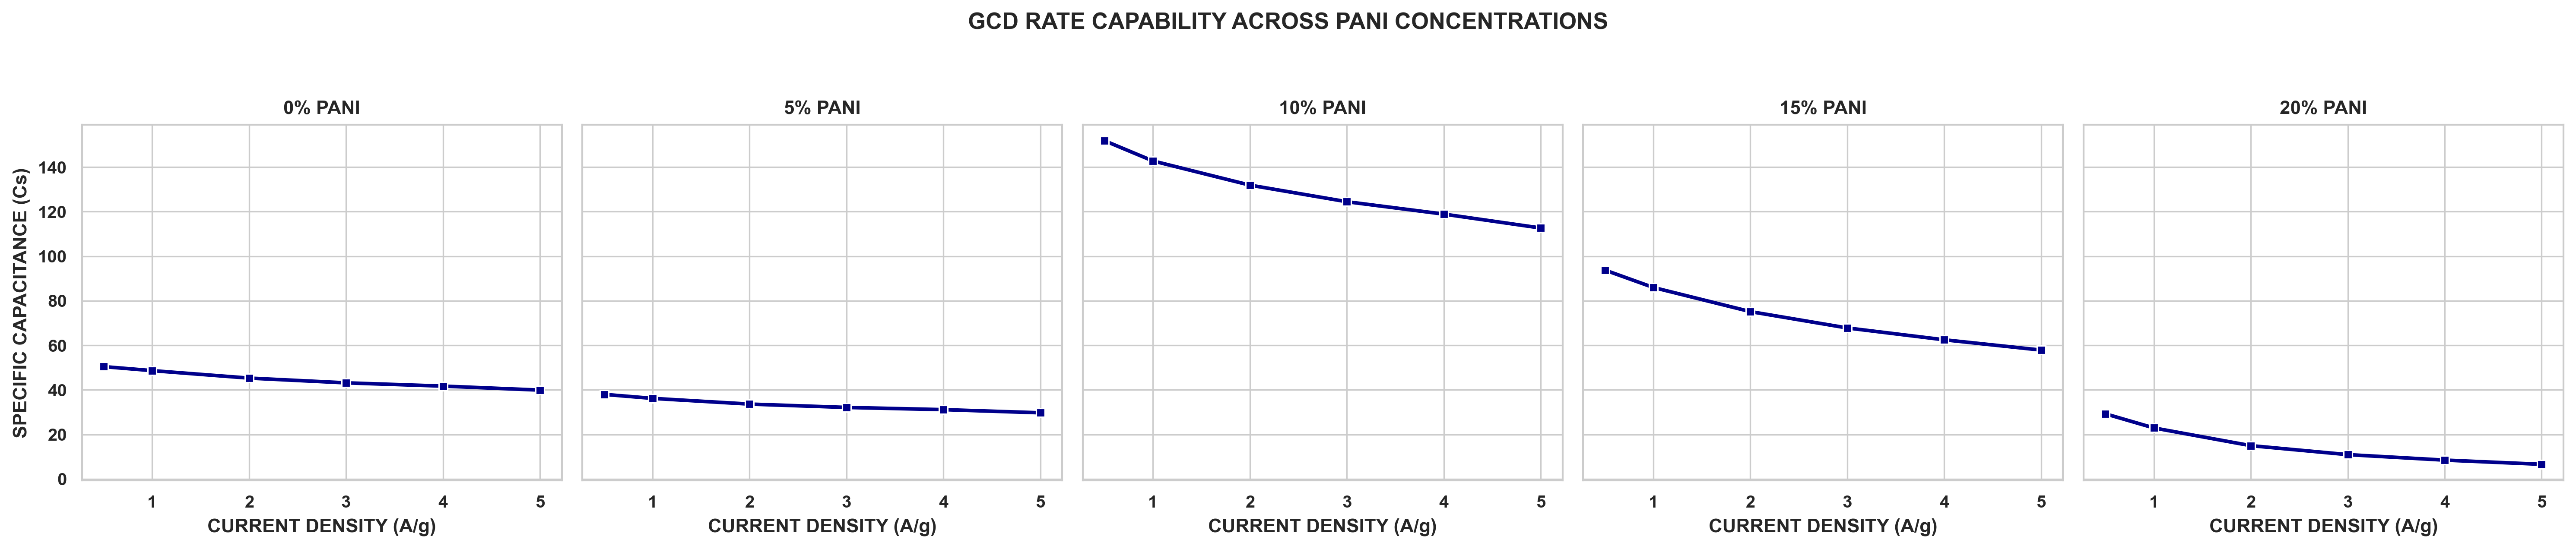

In [30]:
def plot_rate_capability_grid(cv_df: pd.DataFrame, gcd_df: pd.DataFrame):
    """
    PLOTS RATE CAPABILITY (Cs VS KINETIC DRIVING FORCE) FOR ALL CONCENTRATIONS.
    """
    # CV RATE CAPABILITY (1 ROW, 5 COLUMNS)
    fig_cv, axes_cv = plt.subplots(1, 5, figsize=(20, 4), sharey=True, dpi=300)
    fig_cv.suptitle('CV RATE CAPABILITY ACROSS PANI CONCENTRATIONS', fontweight='bold', y=1.05)
    
    for idx, conc in enumerate(pani_levels):
        subset = cv_df[cv_df['PANI_Concentration'] == conc]
        sns.lineplot(data=subset, x='Scan_Rate', y='Cs', marker='o', 
                     color='crimson', linewidth=2, ax=axes_cv[idx])
        axes_cv[idx].set_title(f'{conc}% PANI')
        axes_cv[idx].set_xlabel('SCAN RATE (mV/s)')
        if idx == 0: axes_cv[idx].set_ylabel('SPECIFIC CAPACITANCE (Cs)')
    
    plt.tight_layout()
    plt.show()

    # GCD RATE CAPABILITY (1 ROW, 5 COLUMNS)
    fig_gcd, axes_gcd = plt.subplots(1, 5, figsize=(20, 4), sharey=True, dpi=300)
    fig_gcd.suptitle('GCD RATE CAPABILITY ACROSS PANI CONCENTRATIONS', fontweight='bold', y=1.05)
    
    for idx, conc in enumerate(pani_levels):
        subset = gcd_df[gcd_df['PANI_Concentration'] == conc]
        sns.lineplot(data=subset, x='Current_Density', y='Cs', marker='s', 
                     color='darkblue', linewidth=2, ax=axes_gcd[idx])
        axes_gcd[idx].set_title(f'{conc}% PANI')
        axes_gcd[idx].set_xlabel('CURRENT DENSITY (A/g)')
        if idx == 0: axes_gcd[idx].set_ylabel('SPECIFIC CAPACITANCE (Cs)')

    plt.tight_layout()
    plt.show()

plot_rate_capability_grid(master_cv_df, master_gcd_df)